In [1]:
import pandas as pd 
import seaborn as sns

In [3]:
df=pd.read_csv(r"D:\__Projects\Graduation---Project\DL\Chest-x-ray\data\Chest_xray_Corona_Metadata.csv")

In [4]:
df

,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN
...,...,...,...,...,...,...
5905,5928,person1637_virus_2834.jpeg,Pnemonia,TEST,NaN,Virus
5906,5929,person1635_virus_2831.jpeg,Pnemonia,TEST,NaN,Virus
5907,5930,person1634_virus_2830.jpeg,Pnemonia,TEST,NaN,Virus
5908,5931,person1633_virus_2829.jpeg,Pnemonia,TEST,NaN,Virus


In [5]:
df["Label"].value_counts()

Label
Pnemonia    4334
Normal      1576
Name: count, dtype: int64

In [6]:
df['Label'] =df['Label'].replace('Pnemonia','Pneumonia')
print(df['Label'].value_counts())


Label
Pneumonia    4334
Normal       1576
Name: count, dtype: int64


<Axes: xlabel='Label', ylabel='Count'>

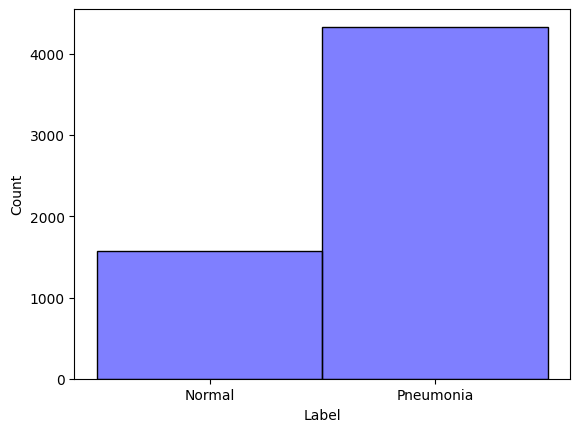

In [7]:
sns.histplot(df['Label'],color='blue',alpha=0.5)

In [8]:
import os
DATASET_DIR = r'D:\__Projects\Graduation---Project\DL\Chest-x-ray\data\Coronahack-Chest-XRay-Dataset'
def get_path(row):
    folder='train' if row['Dataset_type']=='TRAIN' else'test'
    return os.path.join(DATASET_DIR, folder, row['X_ray_image_name'])
df['image_path']=df.apply(get_path, axis=1)


In [9]:
df

,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category,image_path
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN,D:\__Projects\Graduation---Project\DL\Chest-x-...
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN,D:\__Projects\Graduation---Project\DL\Chest-x-...
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN,D:\__Projects\Graduation---Project\DL\Chest-x-...
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN,D:\__Projects\Graduation---Project\DL\Chest-x-...
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN,D:\__Projects\Graduation---Project\DL\Chest-x-...
...,...,...,...,...,...,...,...
5905,5928,person1637_virus_2834.jpeg,Pneumonia,TEST,NaN,Virus,D:\__Projects\Graduation---Project\DL\Chest-x-...
5906,5929,person1635_virus_2831.jpeg,Pneumonia,TEST,NaN,Virus,D:\__Projects\Graduation---Project\DL\Chest-x-...
5907,5930,person1634_virus_2830.jpeg,Pneumonia,TEST,NaN,Virus,D:\__Projects\Graduation---Project\DL\Chest-x-...
5908,5931,person1633_virus_2829.jpeg,Pneumonia,TEST,NaN,Virus,D:\__Projects\Graduation---Project\DL\Chest-x-...


In [10]:
a=df.loc[df["Label"]=="Pneumonia",["image_path"]]
a.value_counts()

image_path                                                                                                                                                 
D:\__Projects\Graduation---Project\DL\Chest-x-ray\data\Coronahack-Chest-XRay-Dataset\test\person100_bacteria_475.jpeg                                          1
D:\__Projects\Graduation---Project\DL\Chest-x-ray\data\Coronahack-Chest-XRay-Dataset\train\person437_bacteria_1884.jpeg                                        1
D:\__Projects\Graduation---Project\DL\Chest-x-ray\data\Coronahack-Chest-XRay-Dataset\train\person431_bacteria_1872.jpeg                                        1
D:\__Projects\Graduation---Project\DL\Chest-x-ray\data\Coronahack-Chest-XRay-Dataset\train\person431_virus_880.jpeg                                            1
D:\__Projects\Graduation---Project\DL\Chest-x-ray\data\Coronahack-Chest-XRay-Dataset\train\person432_virus_881.jpeg                                            1
                                       

In [11]:
df.isna().sum()

Unnamed: 0                   0
X_ray_image_name             0
Label                        0
Dataset_type                 0
Label_2_Virus_category    5841
Label_1_Virus_category    1576
image_path                   0
dtype: int64

In [12]:
df["image_path"].unique()

array(['D:\\__Projects\\Graduation---Project\\DL\\Chest-x-ray\\data\\Coronahack-Chest-XRay-Dataset\\train\\IM-0128-0001.jpeg',
       'D:\\__Projects\\Graduation---Project\\DL\\Chest-x-ray\\data\\Coronahack-Chest-XRay-Dataset\\train\\IM-0127-0001.jpeg',
       'D:\\__Projects\\Graduation---Project\\DL\\Chest-x-ray\\data\\Coronahack-Chest-XRay-Dataset\\train\\IM-0125-0001.jpeg',
       ...,
       'D:\\__Projects\\Graduation---Project\\DL\\Chest-x-ray\\data\\Coronahack-Chest-XRay-Dataset\\test\\person1634_virus_2830.jpeg',
       'D:\\__Projects\\Graduation---Project\\DL\\Chest-x-ray\\data\\Coronahack-Chest-XRay-Dataset\\test\\person1633_virus_2829.jpeg',
       'D:\\__Projects\\Graduation---Project\\DL\\Chest-x-ray\\data\\Coronahack-Chest-XRay-Dataset\\test\\person1632_virus_2827.jpeg'],
      dtype=object)

In [13]:
import os
import time
import copy
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision
from sklearn.metrics import roc_auc_score, confusion_matrix, matthews_corrcoef


c:\Users\nice\anaconda3\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available GPUs:", torch.cuda.device_count())
print("GPU Name:", torch.cuda.get_device_name(0))
print("Current device:", torch.cuda.current_device())

Available GPUs: 1
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
Current device: 0


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.df['label_idx'] = self.df['Label'].map({'Normal': 0, 'Pneumonia': 1}).astype(int)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['label_idx'], dtype=torch.float32)
        return image, label

In [ ]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df[df['Dataset_type'] == 'TRAIN'],
    test_size=0.2,
    random_state=42,
    stratify=df[df['Dataset_type'] == 'TRAIN']['Label'] 
)
test_df = df[df['Dataset_type'] == 'TEST']
train_dataset = ChestXrayDataset(train_df.reset_index(drop=True), transform=train_transform)
val_dataset   = ChestXrayDataset(val_df.reset_index(drop=True),   transform=val_transform)
test_dataset  = ChestXrayDataset(test_df.reset_index(drop=True),  transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)


In [18]:
import torch, gc
def clear_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("gpu memory clear")
clear_gpu_memory()


gpu memory clear


In [67]:
from torchvision.models import resnet18, ResNet18_Weights
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
weights= ResNet18_Weights.IMAGENET1K_V1
model= resnet18(weights=weights)


in_features= model.fc.in_features
model.fc= nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 1)
)
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epoch = 25
for e in range(epoch):
    model.train()
    running_loss = 0.0

    for imgs,labels in train_loader:
        imgs=imgs.to(device)
        labels= labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs= model(imgs)
        loss= criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{e+1}/{epoch}] | training loss: {epoch_loss:.4f}")


Epoch [1/25] | training loss: 0.1703
Epoch [2/25] | training loss: 0.0790
Epoch [3/25] | training loss: 0.0563
Epoch [4/25] | training loss: 0.0524
Epoch [5/25] | training loss: 0.0493
Epoch [6/25] | training loss: 0.0444
Epoch [7/25] | training loss: 0.0362
Epoch [8/25] | training loss: 0.0233
Epoch [9/25] | training loss: 0.0256
Epoch [10/25] | training loss: 0.0198
Epoch [11/25] | training loss: 0.0215
Epoch [12/25] | training loss: 0.0322
Epoch [13/25] | training loss: 0.0226
Epoch [14/25] | training loss: 0.0192
Epoch [15/25] | training loss: 0.0168
Epoch [16/25] | training loss: 0.0160
Epoch [17/25] | training loss: 0.0173
Epoch [18/25] | training loss: 0.0082
Epoch [19/25] | training loss: 0.0099
Epoch [20/25] | training loss: 0.0109
Epoch [21/25] | training loss: 0.0114
Epoch [22/25] | training loss: 0.0083
Epoch [23/25] | training loss: 0.0068
Epoch [24/25] | training loss: 0.0071
Epoch [25/25] | training loss: 0.0080


In [68]:
model.eval()
y_true, y_pred, y_prob =[],[],[]
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs= imgs.to(device)
        labels= labels.to(device).unsqueeze(1)
        outputs= model(imgs)
        probs= torch.sigmoid(outputs)
        preds= (probs > 0.5).float()
        y_true.extend(labels.cpu().numpy().ravel().tolist())
        y_pred.extend(preds.cpu().numpy().ravel().tolist())
        y_prob.extend(probs.cpu().numpy().ravel().tolist())

acc= accuracy_score(y_true, y_pred)
prec= precision_score(y_true, y_pred)
rec= recall_score(y_true, y_pred)
f1= f1_score(y_true, y_pred)
auc= roc_auc_score(y_true, y_prob)

print("baseline model (ResNet18) results:")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

baseline model (ResNet18) results:
Accuracy: 87.18%
Precision: 0.835 | Recall: 0.990 | F1: 0.906 | AUC: 0.937


In [ ]:
import torch

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": "resnet18",
    "num_classes": 1,
    "in_features": model.fc[2].in_features,
    "dropout": 0.5,
    "class_mapping": {"Normal": 0, "Pneumonia": 1},
    "threshold": 0.5,
    "image_size": 224,
    "normalization_mean": [0.485, 0.456, 0.406],
    "normalization_std": [0.229, 0.224, 0.225]
}

torch.save(checkpoint, r"D:\__Projects\Graduation---Project\app\models\chest_xray_best_model.pth")

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model= model
        self.target_layer = target_layer
        self.gradients= None
        self.activations= None
        self.hook_layers()
    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_image, class_idx=None):
        self.model.eval()
        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()
        target = output[0][class_idx]
        target.backward()

        grads= self.gradients
        acts= self.activations
        weights= torch.mean(grads, dim=(2, 3), keepdim=True)
        cam= torch.sum(weights * acts, dim=1).squeeze().cpu().numpy()

        cam= np.maximum(cam, 0)
        cam= cam / cam.max() 
        return cam


c:\Users\nice\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Text(0.5, 1.0, 'overlay (model focus)')

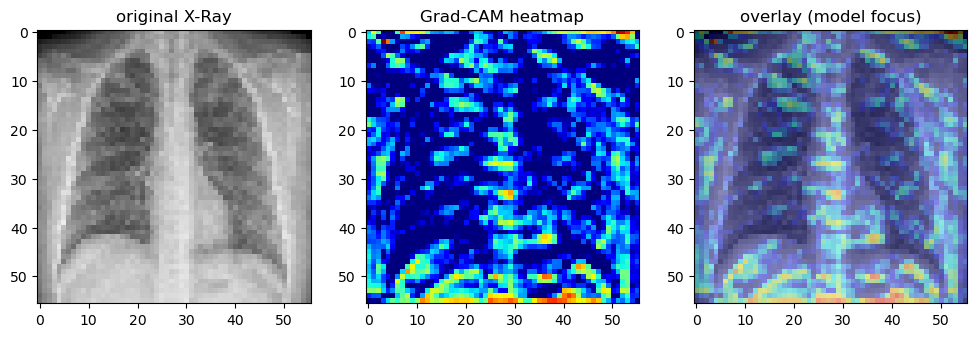

In [ ]:
s= test_df.iloc[0]
img_path=s['image_path']
img = Image.open(img_path).convert('RGB')
transform= val_transform
input_tensor= transform(img).unsqueeze(0).to(device)
target_layer= model.features[-8] 
gradcam= GradCAM(model, target_layer)
cam= gradcam.generate(input_tensor)
img_np= np.array(img)
img_np= cv2.resize(img_np, (cam.shape[1], cam.shape[0]))
heatmap= cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap= cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
superimposed= 0.4 * heatmap + 0.6 * img_np
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("original X-Ray")
plt.subplot(1,3,2)
plt.imshow(cam, cmap='jet')
plt.title("Grad-CAM heatmap")
plt.subplot(1,3,3)
plt.imshow(np.uint8(superimposed))
plt.title("overlay (model focus)")